# Part 1 pipeline walkthrough

Runs the full `apx` pipeline end to end on a tiny, hand-built dataset (a handful of rows per table, same shapes as the real 10k-block pilot's 7 parquet files) so every intermediate DataFrame is small enough to actually read.

Stages: **extraction (synthetic) → load → normalize → classify → core metric engine → results table assembly → validation → report**.

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent / "src"))

import pandas as pd

from apx import basic_data, classify, keys, pipeline, replay
from apx.report import build_report

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 140)

## 1. Synthetic raw data

Mirrors exactly what `extraction.py` would cache as parquet — same 7 tables, same columns — just a handful of rows instead of tens of millions. `address_c` is deliberately upper-case to show normalization lower-casing it in step 3.

In [2]:
def _address(byte: str) -> str:
    return "0x" + byte * 40


def _slot(value: int) -> str:
    return f"0x{value:064x}"


address_a = _address("1")
address_b = _address("2")
address_c = _address("A")  # upper-case on purpose -- normalize should lower-case it

raw_tables = {
    "storage_reads": pd.DataFrame(
        [
            (1, 0, address_a, _slot(0), 3),
            (1, 0, address_a, _slot(8), 1),
            (1, 1, address_b, _slot(64), 2),
            (2, 0, address_a, _slot(300), 4),
            (2, 1, address_c, _slot(1), 1),
        ],
        columns=["block_number", "transaction_index", "address", "slot", "read_count"],
    ),
    "storage_tx_mutations": pd.DataFrame(
        [
            (1, 0, address_a, _slot(0), _slot(0), _slot(1), 1),
            (1, 1, address_b, _slot(64), _slot(2), _slot(3), 1),
            (2, 0, address_a, _slot(300), _slot(4), _slot(0), 1),
        ],
        columns=["block_number", "transaction_index", "address", "slot", "from_value", "to_value", "n_diffs"],
    ),
    "storage_block_mutations": pd.DataFrame(
        [
            (1, address_a, _slot(0), _slot(0), _slot(1), 1),
            (1, address_b, _slot(64), _slot(2), _slot(3), 1),
            (2, address_a, _slot(300), _slot(4), _slot(0), 1),
        ],
        columns=["block_number", "address", "slot", "from_value", "to_value", "n_diffs"],
    ),
    "balance_reads": pd.DataFrame(
        [(1, 0, address_a, 1)], columns=["block_number", "transaction_index", "address", "read_count"]
    ),
    "nonce_reads": pd.DataFrame(
        [(1, 1, address_b, 1)], columns=["block_number", "transaction_index", "address", "read_count"]
    ),
    "balance_block_mutations": pd.DataFrame(
        [(1, address_a, "0", "1"), (2, address_a, "1", "2")],
        columns=["block_number", "address", "from_value", "to_value"],
    ),
    "nonce_block_mutations": pd.DataFrame(
        [(1, address_b, 1, 2)], columns=["block_number", "address", "from_value", "to_value"]
    ),
}

data_dir = Path("_tiny_pipeline_data")
data_dir.mkdir(exist_ok=True)
for name, fname in pipeline._FILES.items():
    raw_tables[name].to_parquet(data_dir / fname, index=False)

raw_tables["storage_reads"]

,block_number,transaction_index,address,slot,read_count
0,1,0,0x1111111111111111111111111111111111111111,0x00000000000000000000000000000000000000000000...,3
1,1,0,0x1111111111111111111111111111111111111111,0x00000000000000000000000000000000000000000000...,1
2,1,1,0x2222222222222222222222222222222222222222,0x00000000000000000000000000000000000000000000...,2
3,2,0,0x1111111111111111111111111111111111111111,0x00000000000000000000000000000000000000000000...,4
4,2,1,0xAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAA,0x00000000000000000000000000000000000000000000...,1


## 2. Load — `pipeline._load_raw`

Reads all 7 parquet files back into DataFrames, unmodified.

In [3]:
raw = pipeline._load_raw(data_dir)
{name: df.shape for name, df in raw.items()}

{'storage_reads': (5, 5),
 'storage_tx_mutations': (3, 7),
 'storage_block_mutations': (3, 6),
 'balance_reads': (1, 4),
 'nonce_reads': (1, 4),
 'balance_block_mutations': (2, 4),
 'nonce_block_mutations': (1, 4)}

## 3. Normalize — `pipeline._normalize_all`

Lower-cases and validates every address/slot column; rows that don't match `0x`+40-hex (address) or `0x`+64-hex (slot) are dropped, with rejection counts kept explicit. Watch `address_c` come back lower-cased below.

In [4]:
clean, rejects = pipeline._normalize_all(raw)
print("rejects:", rejects)
clean["storage_reads"]

rejects: {'storage_reads': {'address_rejected': 0, 'slot_rejected': 0}, 'storage_tx_mutations': {'address_rejected': 0, 'slot_rejected': 0}, 'storage_block_mutations': {'address_rejected': 0, 'slot_rejected': 0}, 'balance_reads': {'address_rejected': 0}, 'nonce_reads': {'address_rejected': 0}, 'balance_block_mutations': {'address_rejected': 0}, 'nonce_block_mutations': {'address_rejected': 0}}


,block_number,transaction_index,address,slot,read_count
0,1,0,0x1111111111111111111111111111111111111111,0x00000000000000000000000000000000000000000000...,3
1,1,0,0x1111111111111111111111111111111111111111,0x00000000000000000000000000000000000000000000...,1
2,1,1,0x2222222222222222222222222222222222222222,0x00000000000000000000000000000000000000000000...,2
3,2,0,0x1111111111111111111111111111111111111111,0x00000000000000000000000000000000000000000000...,4
4,2,1,0xaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaa,0x00000000000000000000000000000000000000000000...,1


## 4. Classify — `classify.classify_reads` / `classify_reads_block`

Adds `is_write_coupled`: True iff the same (block, tx, address, slot) key also shows up as a real (non-no-op) mutation.

In [5]:
reads = classify.classify_reads(clean["storage_reads"], clean["storage_tx_mutations"])
reads

,block_number,transaction_index,address,slot,read_count,is_write_coupled
0,1,0,0x1111111111111111111111111111111111111111,0x00000000000000000000000000000000000000000000...,3,True
1,1,0,0x1111111111111111111111111111111111111111,0x00000000000000000000000000000000000000000000...,1,False
2,1,1,0x2222222222222222222222222222222222222222,0x00000000000000000000000000000000000000000000...,2,True
3,2,0,0x1111111111111111111111111111111111111111,0x00000000000000000000000000000000000000000000...,4,True
4,2,1,0xaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaa,0x00000000000000000000000000000000000000000000...,1,False


In [6]:
reads_block = classify.classify_reads_block(reads, clean["storage_block_mutations"])
reads_block

,block_number,address,slot,is_write_coupled
0,1,0x1111111111111111111111111111111111111111,0x00000000000000000000000000000000000000000000...,True
1,1,0x1111111111111111111111111111111111111111,0x00000000000000000000000000000000000000000000...,False
2,1,0x2222222222222222222222222222222222222222,0x00000000000000000000000000000000000000000000...,True
3,2,0x1111111111111111111111111111111111111111,0x00000000000000000000000000000000000000000000...,True
4,2,0xaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaa,0x00000000000000000000000000000000000000000000...,False


## 5. Core metric engine

The S-sweep machinery in `keys.py`/`replay.py`/`basic_data.py`. Everything here is built to answer *every* header-window size `S` (0..253) from one pass over the data, never a per-S groupby.

### 5a. `keys.slot_low_and_group_key` — the cheap slot decomposition

Splits each slot into `slot_low` (its value 0..255, if it fits in one byte) and a `tree_index_key` string identifying which `slot // 256` group it falls in — done by string-slicing the hex, not by parsing a 256-bit integer.

In [7]:
slot_low, tree_index_key = keys.slot_low_and_group_key(reads["slot"])
pd.DataFrame({"slot": reads["slot"], "slot_low": slot_low, "tree_index_key": tree_index_key})

,slot,slot_low,tree_index_key
0,0x00000000000000000000000000000000000000000000...,0,0000000000000000000000000000000000000000000000...
1,0x00000000000000000000000000000000000000000000...,8,0000000000000000000000000000000000000000000000...
2,0x00000000000000000000000000000000000000000000...,64,0000000000000000000000000000000000000000000000...
3,0x00000000000000000000000000000000000000000000...,<NA>,0000000000000000000000000000000000000000000000...
4,0x00000000000000000000000000000000000000000000...,1,0000000000000000000000000000000000000000000000...


### 5b. `replay.event_locality_curve` — witness/write-cost S-sweep

One histogram + cumulative-sum pass answers "how many events have `slot < S`" for every S at once.

In [8]:
import numpy as np

weight = np.ones(len(reads), dtype=np.float64)
numerator, denom = replay.event_locality_curve(reads["slot"], weight, s_values=[0, 1, 9, 65, 253])
print("total events (denominator):", denom)
pd.Series(numerator, name="events_with_slot_lt_S").rename_axis("S")

total events (denominator): 5.0


S
0      0.0
1      1.0
9      3.0
65     4.0
253    4.0
Name: events_with_slot_lt_S, dtype: float64

### 5c. `replay._stem_group_stats` / `stem_counts` — distinct-stem engine

Per (unit, address) group: `min_low`/`max_low` (touched-slot range within [0,255]) and `n_high` (distinct `tree_index` groups for slots ≥ 256). This tiny per-group table is all `stem_counts` needs to answer the whole S sweep below.

In [9]:
stem_stats = replay._stem_group_stats(reads, unit_cols=["block_number", "transaction_index"])
stem_stats

,block_number,transaction_index,address,min_low,max_low,n_high
0,1,0,0x1111111111111111111111111111111111111111,0,8,0
1,1,1,0x2222222222222222222222222222222222222222,64,64,0
2,2,0,0x1111111111111111111111111111111111111111,<NA>,<NA>,1
3,2,1,0xaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaa,1,1,0


In [10]:
stem_curve = replay.stem_counts(reads, unit_cols=["block_number", "transaction_index"], s_values=[0, 1, 9, 65, 253])
pd.Series(stem_curve, name="distinct_stems").rename_axis("S")

S
0      4.0
1      5.0
9      4.0
65     4.0
253    4.0
Name: distinct_stems, dtype: float64

### 5d. `basic_data.py` — BASIC_DATA co-location proxy

A storage touch "co-locates" with an account's header if that account was also seen in a balance/nonce read or mutation in the same unit. `build_read_proxy` builds the candidate key set; `colocation_curve` sweeps S the same cumulative-histogram way.

In [11]:
read_proxy = basic_data.build_read_proxy(clean["balance_reads"], clean["nonce_reads"])
read_proxy

,block_number,transaction_index,address
0,1,0,0x1111111111111111111111111111111111111111
1,1,1,0x2222222222222222222222222222222222222222


In [12]:
matched, total = basic_data.colocation_curve(
    reads, read_proxy, basic_data.READ_PROXY_KEYS, weight, s_values=[0, 1, 9, 65, 253]
)
pd.DataFrame({"matched": matched, "total": total}).rename_axis("S")

,matched,total
S,,
0,0.0,0.0
1,1.0,1.0
9,2.0,3.0
65,3.0,4.0
253,3.0,4.0


## 6. Results table assembly — the row-builder functions

`pipeline.build_results_table_from_prepared` calls five row-builders and concatenates them into one tidy table. Each one individually, as its own small DataFrame:

In [13]:
s_values = list(range(254))
event_locality_rows = pd.DataFrame(pipeline._event_locality_rows(clean, reads, reads_block, s_values))
event_locality_rows[event_locality_rows["S"].isin([0, 65, 253])]

,metric,series,granularity,placement,S,value,denominator
0,event_locality,is_tx_touched,transaction,n/a,0,0.000000,5.0
65,event_locality,is_tx_touched,transaction,n/a,65,0.800000,5.0
253,event_locality,is_tx_touched,transaction,n/a,253,0.800000,5.0
254,event_locality,is_tx_touched_with_account,transaction,n/a,0,0.000000,5.0
319,event_locality,is_tx_touched_with_account,transaction,n/a,65,0.600000,5.0
507,event_locality,is_tx_touched_with_account,transaction,n/a,253,0.600000,5.0
508,event_locality,is_block_touched,block,n/a,0,0.000000,5.0
573,event_locality,is_block_touched,block,n/a,65,0.800000,5.0
761,event_locality,is_block_touched,block,n/a,253,0.800000,5.0
762,event_locality,is_block_touched_with_account,block,n/a,0,0.000000,5.0


In [14]:
distinct_leaf_rows = pd.DataFrame(pipeline._distinct_leaf_rows(clean, reads, s_values))
distinct_leaf_rows[distinct_leaf_rows["S"].isin([0, 65, 253])]

,metric,series,granularity,placement,S,value,denominator
0,distinct_leaves,reads,transaction,n/a,0,5.0,5.0
65,distinct_leaves,reads,transaction,n/a,65,5.0,5.0
253,distinct_leaves,reads,transaction,n/a,253,5.0,5.0
254,distinct_leaves,reads,block,n/a,0,5.0,5.0
319,distinct_leaves,reads,block,n/a,65,5.0,5.0
507,distinct_leaves,reads,block,n/a,253,5.0,5.0
508,distinct_leaves,tx_write_counts,transaction,n/a,0,3.0,3.0
573,distinct_leaves,tx_write_counts,transaction,n/a,65,3.0,3.0
761,distinct_leaves,tx_write_counts,transaction,n/a,253,3.0,3.0
762,distinct_leaves,block_write_counts,block,n/a,0,3.0,3.0


In [15]:
distinct_stem_rows = pd.DataFrame(pipeline._distinct_stem_rows(clean, reads, s_values))
distinct_stem_rows[distinct_stem_rows["S"].isin([0, 65, 253])]

,metric,series,granularity,placement,S,value,denominator
0,distinct_stems,reads,transaction,compact,0,4.0,4.0
65,distinct_stems,reads,transaction,compact,65,4.0,4.0
253,distinct_stems,reads,transaction,compact,253,4.0,4.0
254,distinct_stems,reads,transaction,current_anchored,0,4.0,4.0
319,distinct_stems,reads,transaction,current_anchored,65,4.0,4.0
447,distinct_stems,reads,block,compact,0,4.0,4.0
512,distinct_stems,reads,block,compact,65,4.0,4.0
700,distinct_stems,reads,block,compact,253,4.0,4.0
701,distinct_stems,reads,block,current_anchored,0,4.0,4.0
766,distinct_stems,reads,block,current_anchored,65,4.0,4.0


In [16]:
basic_data_rows = pd.DataFrame(pipeline._basic_data_rows(clean, reads, s_values))
basic_data_rows[basic_data_rows["S"].isin([0, 65, 253])]

,metric,series,granularity,placement,S,value,denominator
0,basic_data_colocation,read,event,n/a,0,NaN,0.0
65,basic_data_colocation,read,event,n/a,65,0.857143,7.0
253,basic_data_colocation,read,event,n/a,253,0.857143,7.0
254,basic_data_colocation,write,block,n/a,0,NaN,0.0
319,basic_data_colocation,write,block,n/a,65,1.000000,2.0
507,basic_data_colocation,write,block,n/a,253,1.000000,2.0


In [17]:
mutation_kind_rows = pd.DataFrame(pipeline._mutation_kind_rows(clean))
mutation_kind_rows

,metric,series,granularity,placement,S,value,denominator
0,mutation_kind,insertion,transaction,n/a,-1,1.0,1.0
1,mutation_kind,update,transaction,n/a,-1,1.0,1.0
2,mutation_kind,deletion,transaction,n/a,-1,1.0,1.0
3,mutation_kind,insertion,block,n/a,-1,1.0,1.0
4,mutation_kind,update,block,n/a,-1,1.0,1.0
5,mutation_kind,deletion,block,n/a,-1,1.0,1.0


## 7. The final results table

Same call `scripts/run_part1.py` makes, just against our tiny dataset via the shared `PreparedData` (see `pipeline.load_and_classify`) instead of the real pilot's 80M rows.

In [18]:
prepared = pipeline.PreparedData(clean, rejects, reads, reads_block)
results = pipeline.build_results_table_from_prepared(prepared, s_values=range(254))
print(results.shape)
results[results["S"].isin([0, 65, 253])]

(5096, 7)


,metric,series,granularity,placement,S,value,denominator
0,event_locality,is_tx_touched,transaction,n/a,0,0.000000,5.0
65,event_locality,is_tx_touched,transaction,n/a,65,0.800000,5.0
253,event_locality,is_tx_touched,transaction,n/a,253,0.800000,5.0
254,event_locality,is_tx_touched_with_account,transaction,n/a,0,0.000000,5.0
319,event_locality,is_tx_touched_with_account,transaction,n/a,65,0.600000,5.0
507,event_locality,is_tx_touched_with_account,transaction,n/a,253,0.600000,5.0
508,event_locality,is_block_touched,block,n/a,0,0.000000,5.0
573,event_locality,is_block_touched,block,n/a,65,0.800000,5.0
761,event_locality,is_block_touched,block,n/a,253,0.800000,5.0
762,event_locality,is_block_touched_with_account,block,n/a,0,0.000000,5.0


## 8. Validation summary — `pipeline.validation_summary_from_prepared`

Independent reconciliation checks against the same prepared data (partition sums, key-uniqueness, uncovered-key anti-joins).

In [19]:
validation = pipeline.validation_summary_from_prepared(prepared)
validation

{'rejected_counts': {'storage_reads': {'address_rejected': 0,
   'slot_rejected': 0},
  'storage_tx_mutations': {'address_rejected': 0, 'slot_rejected': 0},
  'storage_block_mutations': {'address_rejected': 0, 'slot_rejected': 0},
  'balance_reads': {'address_rejected': 0},
  'nonce_reads': {'address_rejected': 0},
  'balance_block_mutations': {'address_rejected': 0},
  'nonce_block_mutations': {'address_rejected': 0}},
 'read_partition_check': {'n_reads': 5,
  'n_tx_read': 2,
  'n_tx_read_write': 3,
  'partition_holds': True},
 'block_read_partition_check': {'n_block_reads': 5,
  'n_block_read': 2,
  'n_block_read_write': 3,
  'partition_holds': True},
 'read_count_weighted_partition_check': {'total_read_count': 11.0,
  'split_read_count': 11.0,
  'partition_holds': True},
 'storage_tx_mutations_key_unique': True,
 'storage_block_mutations_key_unique': True,
 'tx_write_keys_all_observed_as_reads': {'n_tx_write_keys': 3,
  'n_uncovered': 0,
  'holds': True},
 'block_write_keys_all_obse

## 9. Report + figures — `report.build_report`

Renders `results`/`validation` into `report.md` + figure PNGs. On this tiny dataset the curves are mostly flat/step-shaped (too few rows for a smooth S sweep) — the point here is to see the *pipeline* run end to end, not to read the shapes.

In [20]:
out_dir = Path("_tiny_pipeline_report")
report_path = build_report(results, validation, out_dir)
print("report:", report_path)
print((out_dir / "figures").exists() and sorted(p.name for p in (out_dir / "figures").glob("*.png")))

report: _tiny_pipeline_report/report.md
['leaf_stem_block.png', 'leaf_stem_transaction.png', 'state_root_cost_writes_coaccess.png', 'state_root_cost_writes_pure.png', 'witness_cost_touched.png']


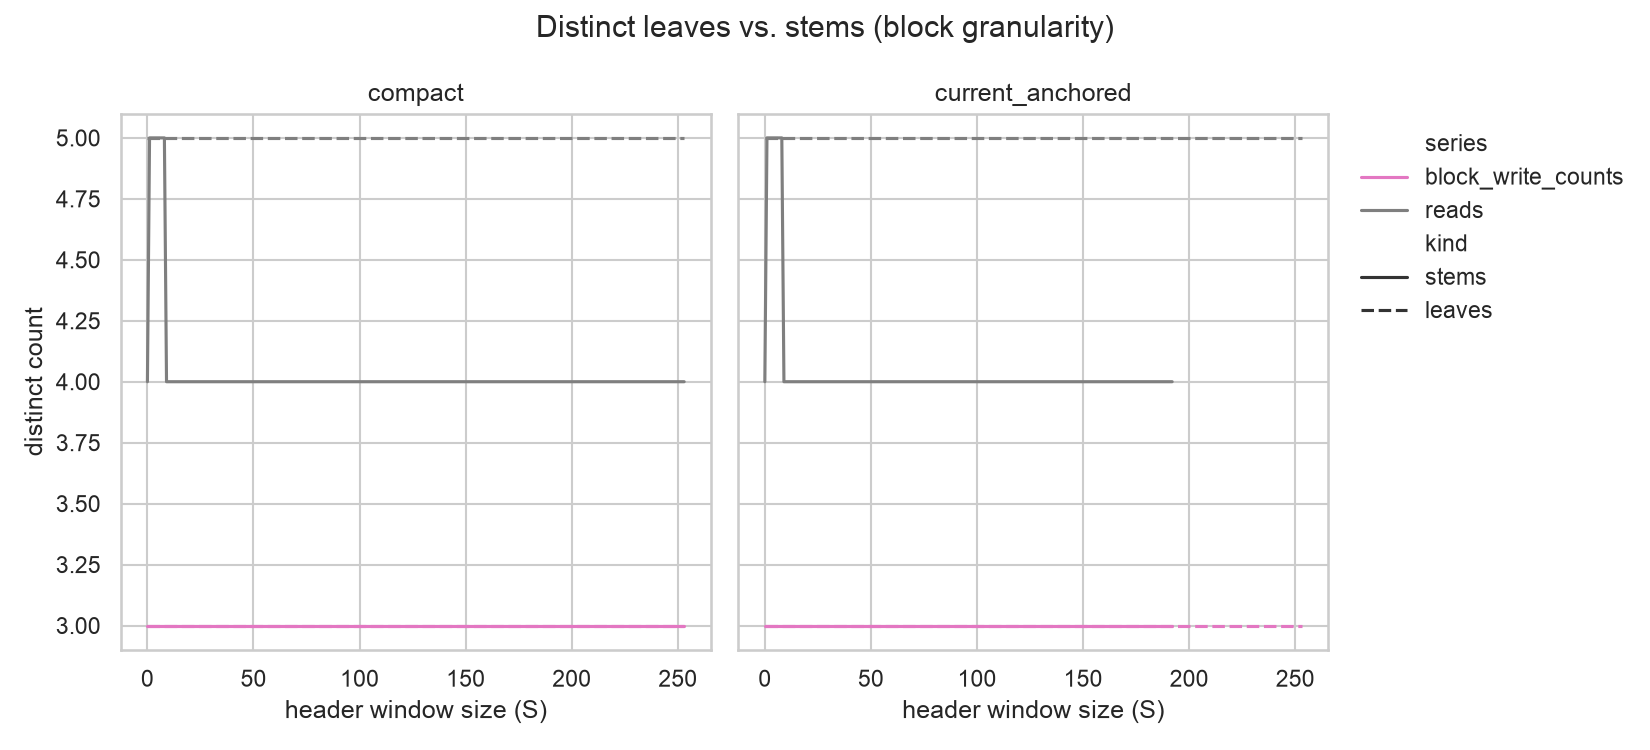

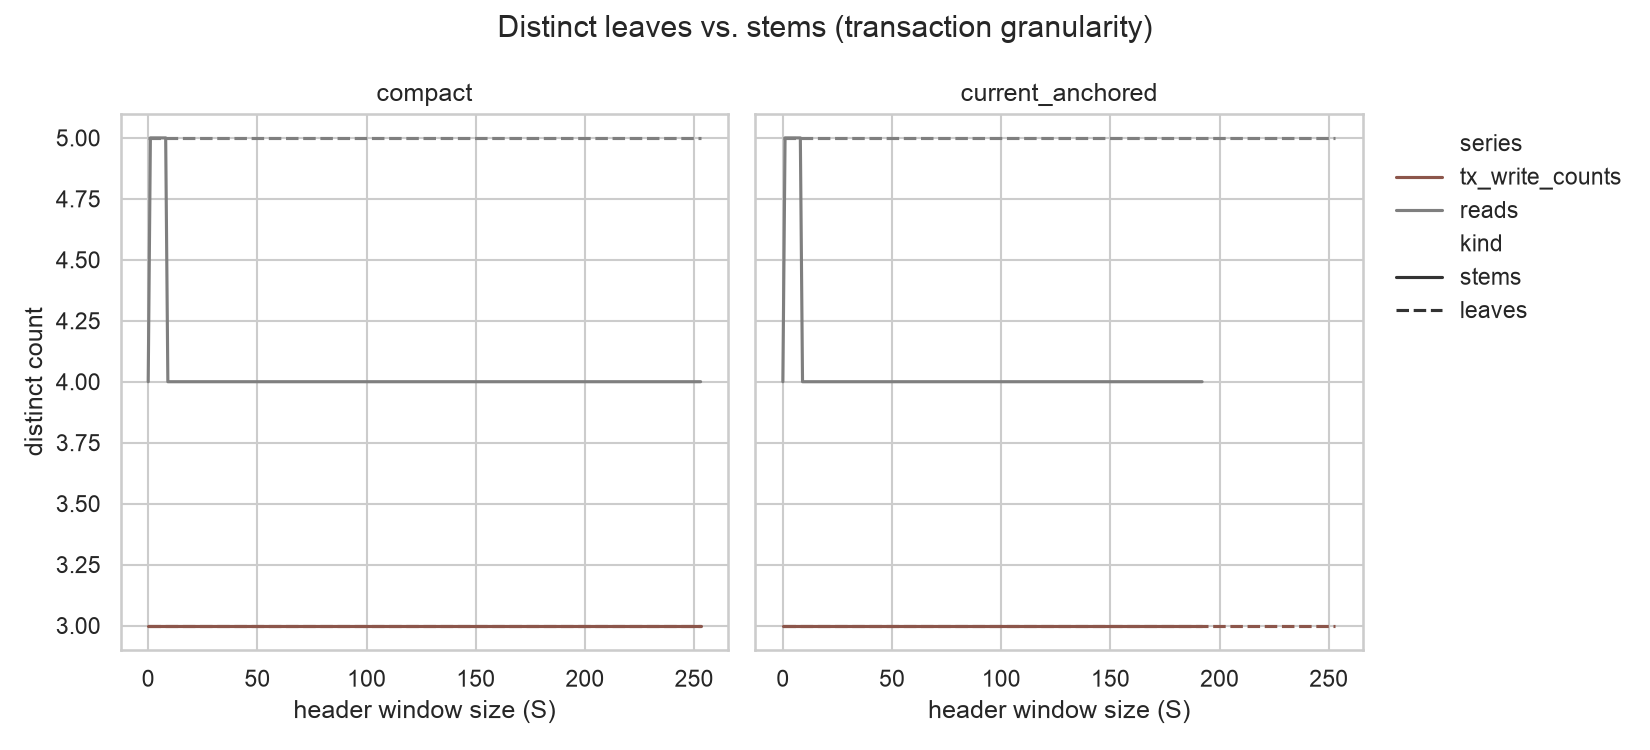

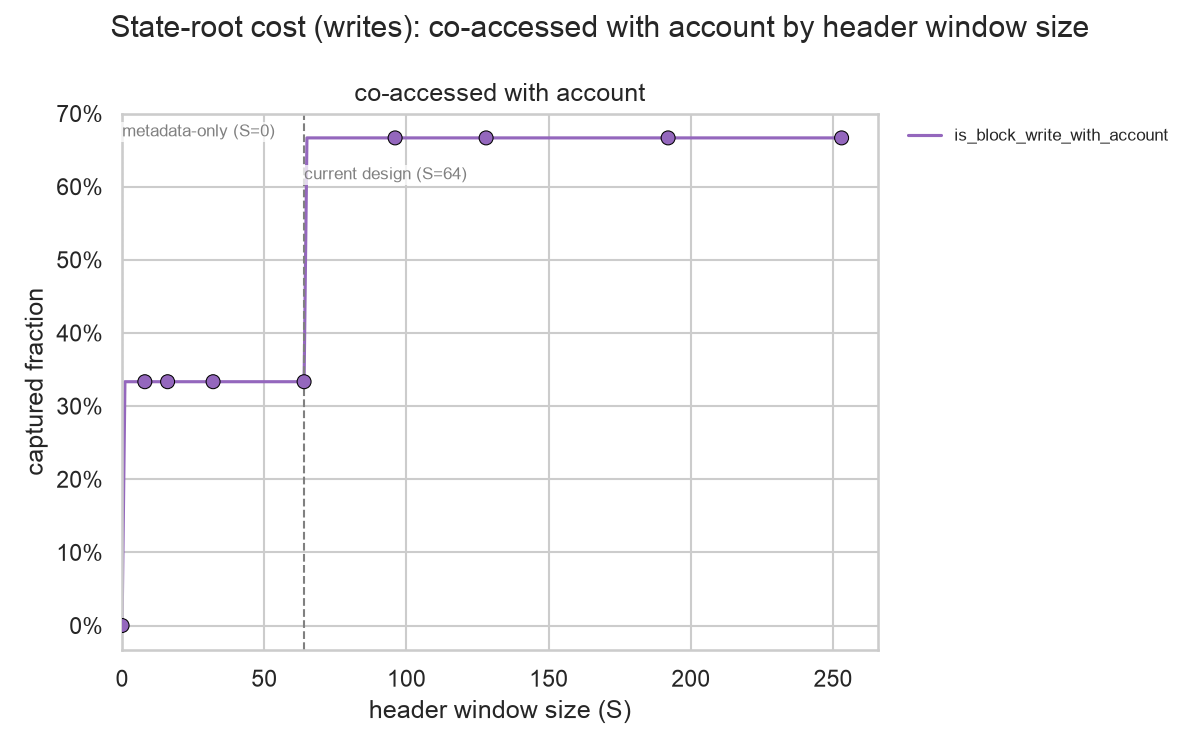

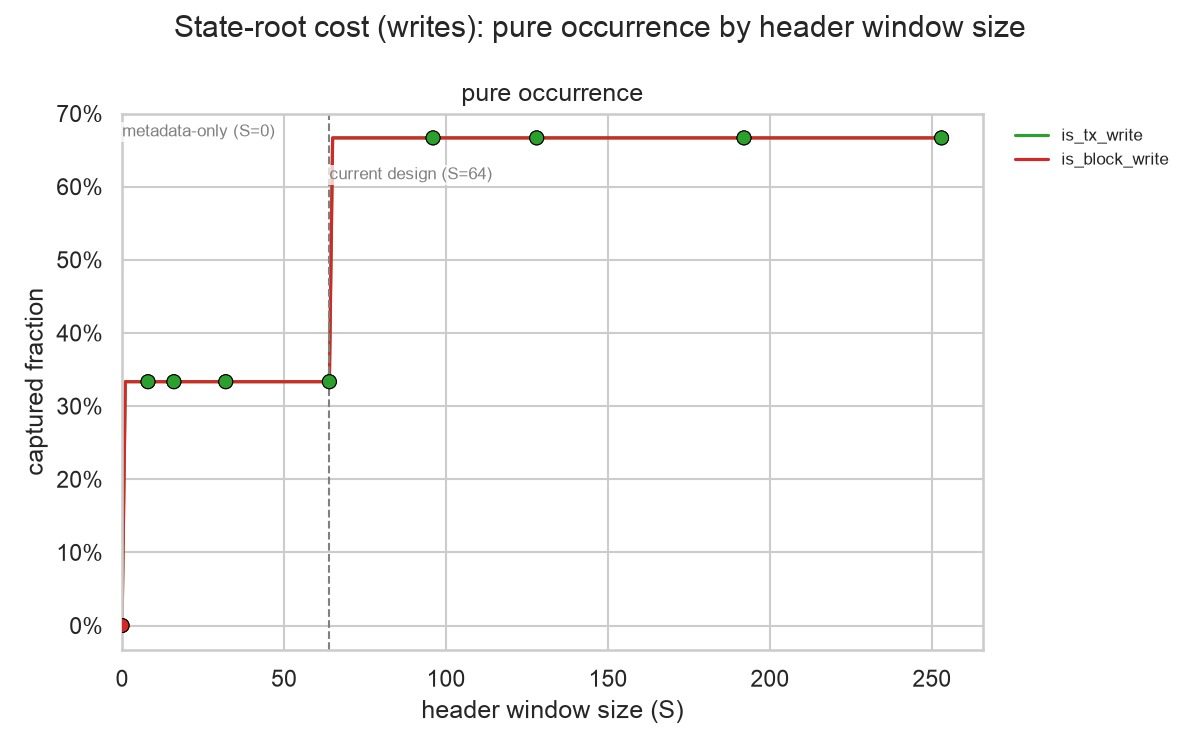

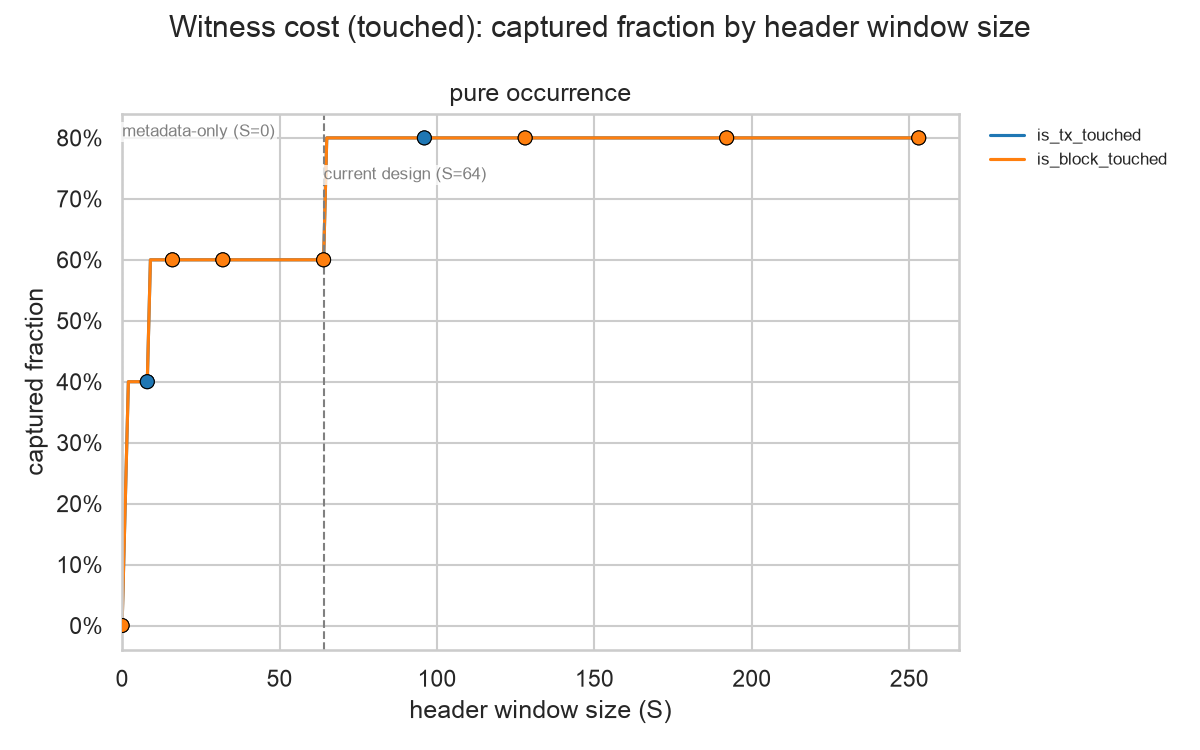

In [21]:
from IPython.display import Image, display

for png in sorted((out_dir / "figures").glob("*.png")):
    display(Image(filename=str(png)))